In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


In [5]:
!ls /kaggle/input/flowers-recognition/flowers

daisy  dandelion  rose	sunflower  tulip


In [7]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

## Split The Data

In [15]:
import splitfolders

input_folder = "/kaggle/input/flowers-recognition/flowers"
output_folder = "/content/flowers-recognition_split"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 0 files [00:00, ? files/s]

Copying files: 4317 files [00:27, 155.00 files/s]


In [16]:
!ls /content/flowers-recognition_split

test  train  val


In [17]:
train_path = "/content/flowers-recognition_split/train"
val_path = "/content/flowers-recognition_split/val"
test_path = "/content/flowers-recognition_split/test"

In [18]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32
)

Found 3019 files belonging to 5 classes.
Found 644 files belonging to 5 classes.
Found 654 files belonging to 5 classes.


In [19]:
class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [20]:
AutoTune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AutoTune)
val_ds = val_ds.cache().prefetch(buffer_size=AutoTune)
test_ds = test_ds.cache().prefetch(buffer_size=AutoTune)

## Sample

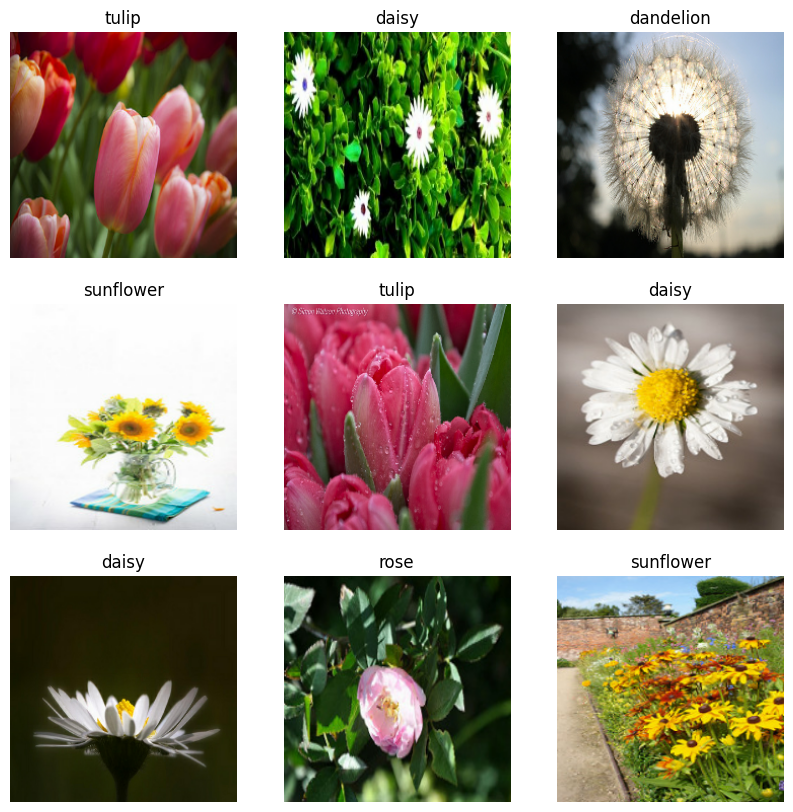

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()